In [1]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task1.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task2.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_task3.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events1.csv", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events2.csv", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="surprise_events3.csv", repo_type="dataset", local_dir="data")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


surprise_task1.h5:   0%|          | 0.00/43.1M [00:00<?, ?B/s]

surprise_task2.h5:   0%|          | 0.00/114M [00:00<?, ?B/s]

surprise_task3.h5:   0%|          | 0.00/135M [00:00<?, ?B/s]

surprise_events1.csv:   0%|          | 0.00/9.85k [00:00<?, ?B/s]

surprise_events2.csv:   0%|          | 0.00/9.84k [00:00<?, ?B/s]

surprise_events3.csv:   0%|          | 0.00/9.85k [00:00<?, ?B/s]

'data/surprise_events3.csv'

# **Task1a**

In [3]:
import os
import h5py
import numpy as np
from scipy.ndimage import zoom
import tensorflow as tf
import matplotlib.pyplot as plt

# Set team name
TEAM_NAME = "irma"

# Define file paths
test_file_path = "data/surprise_task1.h5"  # Test dataset path
model_path = "conv3DLSTM_lightning_prediction_v6.keras"  # Updated model path
output_dir = "predictions/"  # Updated output directory

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Step 1: Compute Actual Min/Max Values from Prediction Data
def compute_min_max(file_path):
    """Computes global min and max values from the prediction dataset."""
    global_min = float("inf")
    global_max = float("-inf")

    with h5py.File(file_path, "r") as f:
        for event_id in f.keys():
            if "vil" in f[event_id]:  # Ensure "vil" data exists
                data = f[event_id]["vil"][:]
                global_min = min(global_min, np.min(data))
                global_max = max(global_max, np.max(data))

    return global_min, global_max

# Compute and store min/max values from prediction dataset
VIL_MIN, VIL_MAX = compute_min_max(test_file_path)
print(f"Computed VIL Min: {VIL_MIN}, Max: {VIL_MAX}")

# Step 2: Define Normalization and Upsampling Functions
def de_min_max_normalize(data, min_val=VIL_MIN, max_val=VIL_MAX):
    """Reverse min-max normalization."""
    return data * (max_val - min_val) + min_val

def upsample(data, target_shape):
    """Upsample data to target resolution."""
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1])
    return zoom(data, zoom_factors, order=1)

def min_max_normalize(data):
    """Apply min-max normalization to data."""
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)

# Step 3: Load and Preprocess the Test Data
def load_prediction_data(file_path, img_types=["vil"], target_shape=(384, 384)):
    """
    Load and preprocess HDF5 data for prediction.

    :param file_path: Path to the HDF5 file.
    :param img_types: List of image types to extract (e.g., ['vil'], ['vis', 'vil'], etc.).
    :param target_shape: Target resolution for upsampling (height, width).
    :return: Dictionary with event IDs as keys and preprocessed data arrays as values.
    """
    prediction_data = {}

    with h5py.File(file_path, "r") as f:
        for event_id in f.keys():  # Iterate through all event IDs
            all_data = []

            for img_type in img_types:
                if img_type not in f[event_id]:
                    print(f"Skipping {event_id}: '{img_type}' not found.")
                    continue

                data = f[event_id][img_type][:]  # Load dataset
                data = np.moveaxis(data, -1, 0)  # Move time to first dimension

                # Normalize and resize each frame
                processed_data = np.array([
                    upsample(min_max_normalize(frame), target_shape) for frame in data
                ])  # Shape: (time, height, width)

                all_data.append(processed_data)

            if all_data:
                # Stack along the last axis to create multi-channel input
                prediction_data[event_id] = np.stack(all_data, axis=-1)  # Shape: (time, height, width, num_channels)

    return prediction_data

# Load test data (single type: "vil")
test_data_single = load_prediction_data(test_file_path, img_types=["vil"])
print(f"Total events loaded: {len(test_data_single)}")

# Step 4: Load the Trained Model
model_conv3DLSTM = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully!")
# Step 5: Iterate Through Events & Predict
for event_id, X_test in test_data_single.items():
    print(f"Predicting event: {event_id} (Shape: {X_test.shape})")

    # Add batch dimension
    X_test = np.expand_dims(X_test, axis=0)  # Shape: (1, 12, 384, 384, 1)

    # Predict using the model
    Y_pred = model_conv3DLSTM.predict(X_test)  # Output Shape: (1, 12, 384, 384, 1)

    # Remove batch dimension & convert dtype to float32
    Y_pred = np.squeeze(Y_pred, axis=0).astype(np.float32)  # Shape: (12, 384, 384, 1)

    # Reshape to (384, 384, 12) - move time dimension to last axis
    Y_pred = np.squeeze(np.moveaxis(Y_pred, 0, -1), axis=2)  # Final Shape: (384, 384, 12)

    # Convert X_test to the same shape as Y_pred
    X_test = np.squeeze(np.moveaxis(X_test[0], 0, -1), axis=2)  # Shape: (384, 384, 12)

    # Debug: Print final shapes before saving
    print(f"Final X_test Shape: {X_test.shape}, Final Y_pred Shape: {Y_pred.shape}, dtype: {Y_pred.dtype}")

    # Save in correct filename format
    filename = f"{TEAM_NAME}-task1a-vil-{event_id}.npy"
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, Y_pred)

    # **New Addition: Confirm the saved file shape**
    loaded_Y_pred = np.load(filepath)  # Reload the saved file to confirm shape
    print(f"Saved numpy file shape: {loaded_Y_pred.shape}, dtype: {loaded_Y_pred.dtype}")

print("All predictions completed and saved in the correct format!")

Computed VIL Min: 0, Max: 254
Total events loaded: 10
Model loaded successfully!
Predicting event: S837416 (Shape: (12, 384, 384, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Final X_test Shape: (384, 384, 12), Final Y_pred Shape: (384, 384, 12), dtype: float32
Saved numpy file shape: (384, 384, 12), dtype: float32
Predicting event: S843931 (Shape: (12, 384, 384, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Final X_test Shape: (384, 384, 12), Final Y_pred Shape: (384, 384, 12), dtype: float32
Saved numpy file shape: (384, 384, 12), dtype: float32
Predicting event: S844398 (Shape: (12, 384, 384, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Final X_test Shape: (384, 384, 12), Final Y_pred Shape: (384, 384, 12), dtype: float32
Saved numpy file shape: (384, 384, 12), dtype: float32
Predicting event: S849444 (Shape: (12, 384, 384, 1))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Final X_test Shape: (384, 384, 12), Final Y_pred Shape: (384, 384, 12), dtype: float32
Saved numpy file shape: (384, 384, 12), dtyp

# **Task1b**

In [6]:
!pip install tensorflow.keras

In [19]:
import tensorflow as tf
from tensorflow.keras.losses import Loss

@tf.keras.utils.register_keras_serializable(package="CustomLoss")
class MSE_SSIM_Loss(Loss):
    def __init__(self, alpha=0.9, beta=0.1, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.beta = beta

    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
        return self.alpha * mse + self.beta * (1 - tf.reduce_mean(ssim))

    def get_config(self):
        config = super().get_config()
        config.update({"alpha": self.alpha, "beta": self.beta})
        return config

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
def attention(x):
    """ Temporal attention mechanism that assigns higher weight to later frames. """
    batch_size = tf.shape(x)[0]
    t_weight = tf.range(1, 13, dtype=tf.float32) / 12.0  # Generate weights for 12 frames
    t_weight = tf.reshape(t_weight, (1, 12, 1, 1, 1))
    t_weight = tf.tile(t_weight, [batch_size, 1, 1, 1, x.shape[-1]])  # Expand along batch and channel dimensions
    return Multiply()([x, t_weight])

def temporal_attention_layer():
    """ Applies the temporal attention mechanism using a Lambda layer. """
    return Lambda(attention, name="temporal_attention")

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class RecursiveLSTMLayer(tf.keras.layers.Layer):
    """ Recursive ConvLSTM2D layer to predict future frames (t=13 to t=24). """
    def __init__(self, units, output_length, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.output_length = output_length
        self.lstm = ConvLSTM2D(units, (3, 3), activation=None, padding='same', return_sequences=True)

    def call(self, inputs):
        outputs = []
        x = inputs[:, -1:, :, :, :]  # Use only the last frame (t=12) as the initial input
        for _ in range(self.output_length):
            x = self.lstm(x)  # Recursively feed the predicted frame back into LSTM
            outputs.append(x)

        return tf.concat(outputs, axis=1)  # Concatenate all predicted frames along the time axis


import numpy as np
import h5py
from tensorflow.keras.models import load_model
from scipy.ndimage import zoom

import os
import numpy as np
import h5py
from tensorflow.keras.models import load_model
from scipy.ndimage import zoom

# Define team name
TEAM_NAME = "Irma"

# Normalization function
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

# Denormalization function
def denormalize(data, min_val, max_val):
    return data * (max_val - min_val + 1e-8) + min_val

# Upsampling function
def upsample(data, target_shape=(384, 384)):
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1])
    return zoom(data, zoom_factors, order=1)

# Load test dataset
test_file = "data/surprise_task1.h5"
with h5py.File(test_file, "r") as f:
    event_ids = list(f.keys())  # Retrieve all event IDs
    print("Total number of events:", len(event_ids))

# Ensure output directory exists
output_dir = "predictions"
os.makedirs(output_dir, exist_ok=True)

# Process all events
for event_id in event_ids:
    with h5py.File(test_file, "r") as f:
        event = {img_type: f[event_id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil']}

    print(f"Processing event {event_id}...")

    # Normalize the data
    vis_norm, vis_min, vis_max = min_max_normalize(event["vis"])
    ir069_norm, ir069_min, ir069_max = min_max_normalize(event["ir069"])
    ir107_norm, ir107_min, ir107_max = min_max_normalize(event["ir107"])
    vil_norm, vil_min, vil_max = min_max_normalize(event["vil"])

    # Upsample ir069 and ir107 to (384, 384)
    ir069_up = np.array([upsample(frame) for frame in np.moveaxis(ir069_norm, -1, 0)])  # Shape: (12, 384, 384)
    ir107_up = np.array([upsample(frame) for frame in np.moveaxis(ir107_norm, -1, 0)])  # Shape: (12, 384, 384)

    # Prepare input data (12, 384, 384, 4)
    X_test = np.stack([
        np.moveaxis(vis_norm, -1, 0),  # (12, 384, 384)
        ir069_up,  # (12, 384, 384)
        ir107_up,  # (12, 384, 384)
        np.moveaxis(vil_norm, -1, 0)  # (12, 384, 384)
    ], axis=-1)  # Shape: (12, 384, 384, 4)

    # Add batch dimension
    X_test = np.expand_dims(X_test, axis=0)  # Shape: (1, 12, 384, 384, 4)
    print("Input X_test shape:", X_test.shape)

    # Load the model
    model = load_model("unet_convlstm_model.keras", custom_objects={"RecursiveLSTMLayer": RecursiveLSTMLayer, "attention": attention})

    # Make predictions
    Y_pred = model.predict(X_test)  # Shape: (1, 12, 384, 384, 1)
    print("Output Y_pred shape:", Y_pred.shape)

    # Denormalize the predicted output
    Y_pred = np.squeeze(Y_pred, axis=0)  # Shape: (12, 384, 384, 1) → (12, 384, 384)
    Y_pred = denormalize(Y_pred, vil_min, vil_max)
    Y_pred = np.squeeze(Y_pred, axis=-1)  # Shape: (12, 384, 384)

    # Convert shape from (12, 384, 384) to (384, 384, 12)
    Y_pred = np.transpose(Y_pred, (1, 2, 0))  # Swap axes to place the time dimension last
    print("Final Y_pred shape:", Y_pred.shape)

    # Save predictions for Task 1B
    filename = f"{TEAM_NAME}-task1b-vil-{event_id}.npy"
    np.save(os.path.join(output_dir, filename), Y_pred.astype(np.float32))

print(f"All events processed successfully. Predictions saved in {output_dir}.")



Total number of events: 10
Processing event S837416...
Input X_test shape: (1, 12, 384, 384, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'recursive_lstm_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S843931...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S844398...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S849444...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S849552...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred shape: (384, 384, 12)
Processing event S851111...
Input X_test shape: (1, 12, 384, 384, 4)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Output Y_pred shape: (1, 12, 384, 384, 1)
Final Y_pred

# **Task1b Justification**

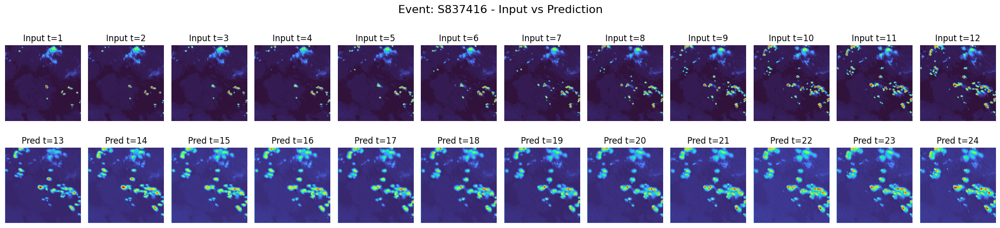

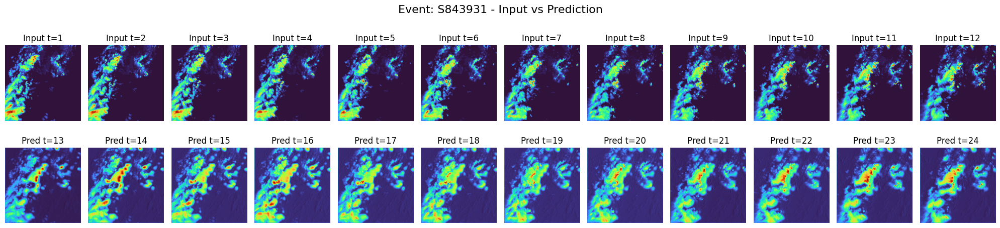

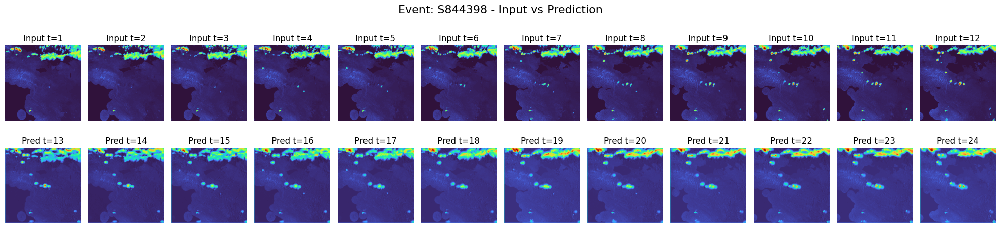

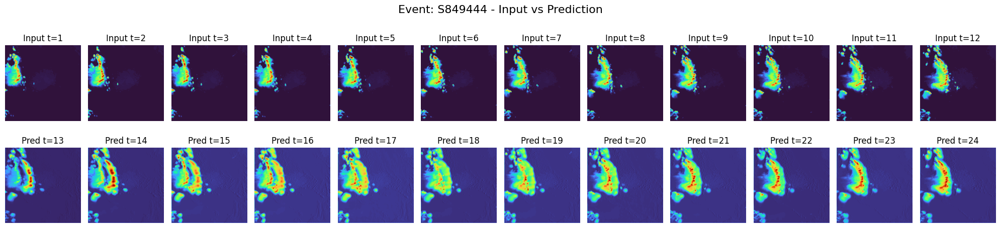

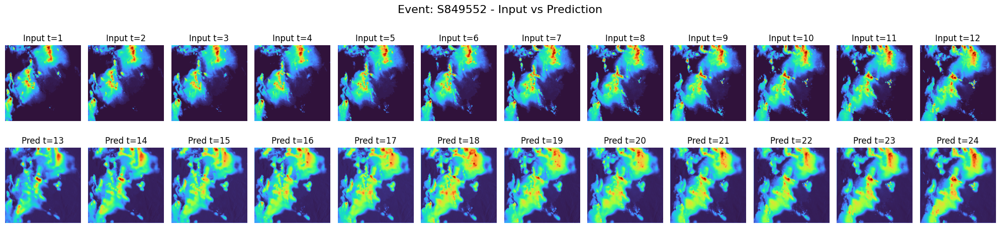

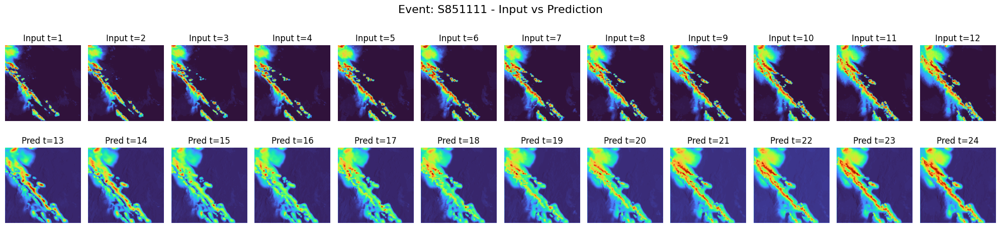

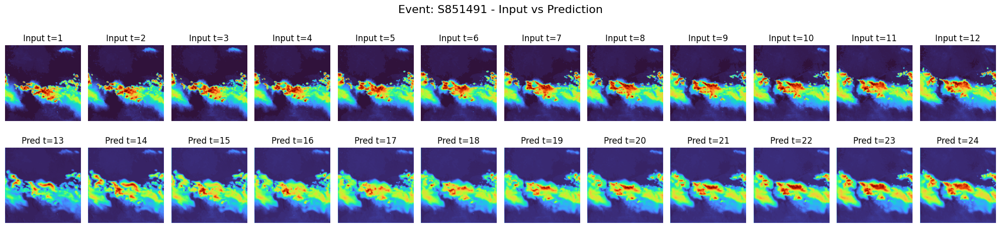

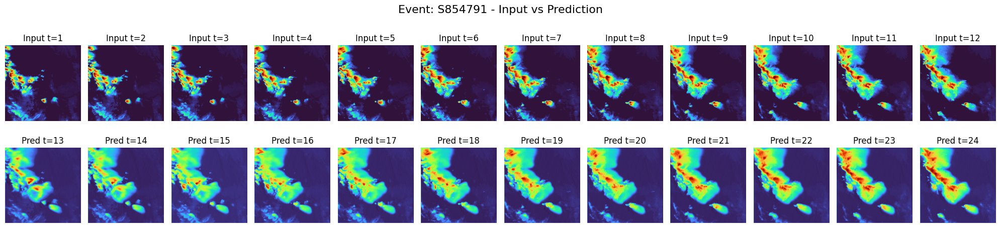

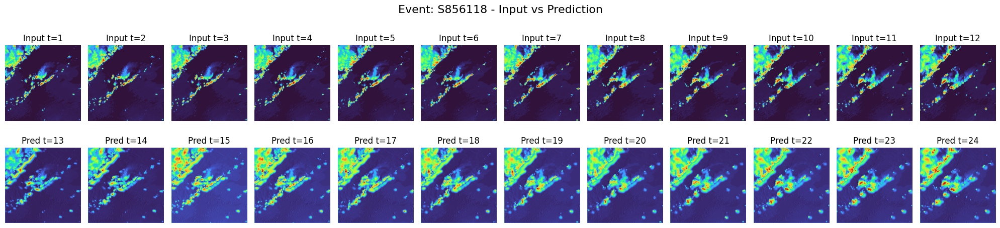

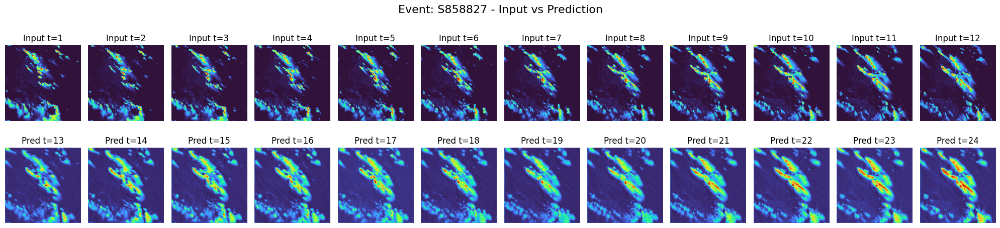

In [20]:
for event_id in event_ids:
    with h5py.File(test_file, "r") as f:
        vil_test = f[event_id]["vil"][:]  # Shape: (384, 384, 12)

    if event_id not in predictions:
        print(f"Skipping event {event_id}, no prediction available.")
        continue

    vil_pred = predictions[event_id]  # Shape: (384, 384, 12)

    fig, axes = plt.subplots(2, 12, figsize=(20, 5))  # 2 rows, 12 columns

    for t in range(12):
        # **Plot Ground Truth**
        axes[0, t].imshow(vil_test[:, :, t], cmap="turbo")
        axes[0, t].axis("off")
        axes[0, t].set_title(f"Input t={t+1}")

        # **Plot Prediction**
        axes[1, t].imshow(vil_pred[:, :, t], cmap="turbo")
        axes[1, t].axis("off")
        axes[1, t].set_title(f"Pred t={t+13}")

    plt.suptitle(f"Event: {event_id} - Input vs Prediction", fontsize=16)
    plt.tight_layout()
    plt.show()

Comparison:
Temporal: 1b learns more about temporal features, with continuity between the image at t=13 and input t=12;
Structural: for different colour blocks, 1b predicts the highlighted yellow and red parts more clearly;
Colour bias: both have a slight colour bias in the base colour, with 1b being significantly bluer.

# **Task2**

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import numpy as np
import os

# Task 2 event IDs
task2_ids = [
    'S852507', 'S834438', 'S847775', 'S838836', 'S851858',
    'S851835', 'S849415', 'S847917', 'S855381', 'S843625'
]

DATA_PATH = "data/surprise_task2.h5"
PREDICTION_DIR = "predictions/"
TEAM_NAME = "Irma"

# Ensure output directory exists
os.makedirs(PREDICTION_DIR, exist_ok=True)

# Define the U-Net-based Generator for GAN
class UNet_GAN(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet_GAN, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 512)

        # Decoder
        self.up3 = self.up_conv(512, 256)
        self.dec3 = self.conv_block(512, 256)
        self.up2 = self.up_conv(256, 128)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = self.up_conv(128, 64)
        self.dec1 = self.conv_block(128, 64)

        # Final layer (without Tanh)
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
        self.tanh = nn.Tanh()  # Apply Tanh separately

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(F.max_pool2d(enc1, 2))
        enc3 = self.enc3(F.max_pool2d(enc2, 2))

        bottleneck = self.bottleneck(F.max_pool2d(enc3, 2))

        up3 = self.up3(bottleneck)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

        return self.tanh(self.final(dec1))  # Apply Tanh separately

# Load GAN model
MODEL_PATH = "gan_best_model_epoch20.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and load the model
model = UNet_GAN(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()  # Set to evaluation mode

print("GAN model loaded successfully!")

def normalize_minmax(data):
    """Normalize data to range [0, 1] using Min-Max scaling."""
    return (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-6)

# Load Task 2 dataset and generate predictions
with h5py.File(DATA_PATH, 'r') as f:
    for event_id in task2_ids:
        print(f"\nProcessing event: {event_id}")

        # Load input data
        vis = f[event_id]['vis'][:]  # Shape (384, 384, 36)
        ir069 = f[event_id]['ir069'][:]  # Shape (192, 192, 36)
        ir107 = f[event_id]['ir107'][:]  # Shape (192, 192, 36)

        # Convert ir069 and ir107 to PyTorch tensors and resize
        ir069_resized = torch.tensor(ir069, dtype=torch.float32).unsqueeze(0)  # Shape: (1, 192, 192, 36)
        ir107_resized = torch.tensor(ir107, dtype=torch.float32).unsqueeze(0)  # Shape: (1, 192, 192, 36)

        # Reshape tensors for interpolation (move frame dimension to batch)
        ir069_resized = ir069_resized.permute(3, 0, 1, 2)  # Shape: (36, 1, 192, 192)
        ir107_resized = ir107_resized.permute(3, 0, 1, 2)  # Shape: (36, 1, 192, 192)

        # Resize to (384, 384)
        ir069_resized = F.interpolate(ir069_resized, size=(384, 384), mode='bilinear', align_corners=False)
        ir107_resized = F.interpolate(ir107_resized, size=(384, 384), mode='bilinear', align_corners=False)

        # Convert back to numpy format
        ir069_resized = ir069_resized.squeeze().permute(1, 2, 0).numpy()
        ir107_resized = ir107_resized.squeeze().permute(1, 2, 0).numpy()

        # Normalize input data to [0, 1]
        vis = normalize_minmax(vis)
        ir069_resized = normalize_minmax(ir069_resized)
        ir107_resized = normalize_minmax(ir107_resized)

        # Initialize storage for 36 frames
        output_numpy = np.zeros((384, 384, 36), dtype=np.float32)

        # Predict each frame separately
        for i in range(36):
            try:
                input_tensor = np.stack([vis[:, :, i], ir069_resized[:, :, i], ir107_resized[:, :, i]], axis=0)
                input_tensor = torch.tensor(input_tensor, dtype=torch.float32).unsqueeze(0).to(device)

                # Make prediction
                with torch.no_grad():
                    output = model(input_tensor)  # Output shape: (1, 1, 384, 384)

                # Convert output from Tanh (-1 to 1) to [0, 255] while keeping float32
                output_numpy[:, :, i] = ((output.squeeze().cpu().numpy() + 1) / 2.0) * 255.0  # Scale [-1,1] → [0,255]

            except Exception as e:
                print(f"  ⚠️ Error processing frame {i} of {event_id}: {e}")
                continue

        # Ensure the output is in float32 format
        output_numpy = output_numpy.astype(np.float32)  # Keep as float32

        # Save predictions
        output_file = f"{PREDICTION_DIR}/{TEAM_NAME}-task2-vil-{event_id}.npy"
        np.save(output_file, output_numpy)

        print(f"✅ Saved normalized GAN prediction for {event_id} to {output_file}")

print("🎉 All Task 2 GAN predictions normalized and saved successfully!")


<ipython-input-18-4241b40e90e3>:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


GAN model loaded successfully!

Processing event: S852507
✅ Saved normalized GAN prediction for S852507 to predictions//Irma-task2-vil-S852507.npy

Processing event: S834438
✅ Saved normalized GAN prediction for S834438 to predictions//Irma-task2-vil-S834438.npy

Processing event: S847775
✅ Saved normalized GAN prediction for S847775 to predictions//Irma-task2-vil-S847775.npy

Processing event: S838836
✅ Saved normalized GAN prediction for S838836 to predictions//Irma-task2-vil-S838836.npy

Processing event: S851858
✅ Saved normalized GAN prediction for S851858 to predictions//Irma-task2-vil-S851858.npy

Processing event: S851835
✅ Saved normalized GAN prediction for S851835 to predictions//Irma-task2-vil-S851835.npy

Processing event: S849415
✅ Saved normalized GAN prediction for S849415 to predictions//Irma-task2-vil-S849415.npy

Processing event: S847917
✅ Saved normalized GAN prediction for S847917 to predictions//Irma-task2-vil-S847917.npy

Processing event: S855381
✅ Saved normal